# 03 — Modeling baselines and model comparison

Trains and evaluates baseline + first-pass models across the **three target framings** required by the revised spec:

- **Task A (primary)**: multiclass era classification — 6 era bins.
- **Task B**: binary pre/post-1975 classification (RT1974 regulatory threshold).
- **Task C**: regression on exact construction year (restricted to rows with a non-null `annee_construction`).

Each task uses the **same cleaned features and the same train/test split** computed in `02_cleaning_eda.ipynb`, so results are directly comparable.

Includes the four-way feature ablation called out by the spec (energy-only, structural-only, combined, combined-minus-leaky) on the primary multiclass task.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

## 1. Configuration

The cleaned dataset already contains both the **features** and the **three targets**, plus a `split` column that marks the 80/20 stratified hold-out computed in `02`. The modeling notebook never re-splits — it just reads that column.

In [2]:
from pathlib import Path

DATA_PATH = Path("../data/cleaned/dpe_clean_model_ready.parquet")
OUTPUT_DIR = Path("../reports/modeling")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Target columns (see 02_cleaning_eda.ipynb)
TARGET_ERA = "construction_era"        # multiclass (6 bins)
TARGET_BINARY = "pre_post_1975"         # binary
TARGET_YEAR = "annee_construction"      # regression (exact year)

# Columns to exclude from the feature matrix.
# These are either targets or administrative metadata - keeping any of them as features
# would leak the answer into the inputs.
DROP_COLS = [TARGET_ERA, TARGET_BINARY, TARGET_YEAR, "target_source", "split"]

## 2. Feature catalogue

These lists are kept in sync with `02_cleaning_eda.ipynb`. Defining them explicitly (instead of keyword-matching column names) means engineered features like `all_electric` and `insulation_indicator` are correctly classified into the energy / structural / geographic groups used in the ablation.

In [3]:
ENERGY_FEATURES = [
    "conso_5_usages_par_m2_ep",
    "emission_ges_5_usages_par_m2",
    "etiquette_dpe",
    "etiquette_ges",
    "conso_chauffage_ep",
    "conso_ecs_ep",
    "conso_refroidissement_ep",
    "conso_eclairage_ep",
    "conso_auxiliaires_ep",
]

STRUCTURAL_FEATURES = [
    "surface_habitable_logement",
    "type_batiment",
    "nombre_niveau_logement",
    "qualite_isolation_murs",
    "qualite_isolation_menuiseries",
    "type_generateur_chauffage_principal",
    "type_energie_principale_chauffage",
    "type_installation_ecs",
    "type_energie_principale_ecs",
    "type_ventilation",
    "isolation_toiture",
    "qualite_isolation_plancher_bas",
    "classe_inertie_batiment",
]

GEO_FEATURES = [
    "code_departement_ban",
    "zone_climatique",
    "classe_altitude",
]

# Engineered features grouped by parent category (for the ablation)
ENGINEERED_ENERGY = ["heating_to_hot_water_ratio", "energy_per_floor"]
ENGINEERED_STRUCTURAL = ["all_electric", "climate_heating_combo", "insulation_indicator"]

# Potentially leaky features: equipment types that may trivially encode era
# (e.g. oil boilers -> 1970s, heat pumps -> 2010s). Spec section 6 / experiment 4.
LEAKY_FEATURES = ["type_generateur_chauffage_principal", "type_ventilation"]

ALL_FEATURES = ENERGY_FEATURES + STRUCTURAL_FEATURES + GEO_FEATURES + ENGINEERED_ENERGY + ENGINEERED_STRUCTURAL
print(f"Total features: {len(ALL_FEATURES)}")

Total features: 30


## 3. Load cleaned dataset

In [4]:
df = pd.read_parquet(DATA_PATH)
print(f"Loaded {DATA_PATH}: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Sanity check: every column we expect is present
missing = [c for c in ALL_FEATURES + DROP_COLS if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns in cleaned dataset: {missing}")

df.head()

Loaded ../data/cleaned/dpe_clean_model_ready.parquet: 49,921 rows x 35 columns


,annee_construction,construction_era,pre_post_1975,target_source,conso_5_usages_par_m2_ep,emission_ges_5_usages_par_m2,etiquette_dpe,etiquette_ges,conso_chauffage_ep,conso_ecs_ep,...,classe_inertie_batiment,code_departement_ban,zone_climatique,classe_altitude,heating_to_hot_water_ratio,energy_per_floor,all_electric,climate_heating_combo,insulation_indicator,split
0,NaN,2013+,post-1975,periode_construction,66.0,13.0,C,C,1327.3,1442.7,...,Légère,06,H3,inférieur à 400m,0.920011,66.0,0,H3__Gaz naturel,3.5,train
1,NaN,pre-1948,pre-1975,periode_construction,319.0,42.0,E,D,5910.3,2626.2,...,Lourde,75,H1a,inférieur à 400m,2.250514,319.0,0,H1a__Réseau de Chauffage urbain,1.0,train
2,NaN,1975-1988,post-1975,periode_construction,141.0,5.0,C,A,8176.2,3906.7,...,Légère,33,H2c,inférieur à 400m,2.092866,70.5,1,H2c__Électricité,1.5,train
3,2010.0,2001-2012,post-1975,annee_construction,126.5,4.8,C,A,5817.3,4954.7,...,Légère,14,H1a,inférieur à 400m,1.174097,126.5,1,H1a__Électricité,3.5,train
4,NaN,1989-2000,post-1975,periode_construction,220.0,33.0,C,C,1906.6,1532.0,...,Lourde,92,H1a,inférieur à 400m,1.244517,220.0,0,H1a__Réseau de Chauffage urbain,3.0,test


## 4. Use the pre-computed train/test split

The 80/20 stratified hold-out lives in the `split` column. We just apply the mask — no `train_test_split` call here, so the modeling notebook can never diverge from the cleaning notebook's split.

In [5]:
train_mask = df["split"] == "train"
test_mask = df["split"] == "test"

X = df[ALL_FEATURES].copy()
y_era = df[TARGET_ERA].astype(str)
y_binary = df[TARGET_BINARY].astype(str)
y_year = pd.to_numeric(df[TARGET_YEAR], errors="coerce")

X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_era_train, y_era_test = y_era.loc[train_mask], y_era.loc[test_mask]
y_binary_train, y_binary_test = y_binary.loc[train_mask], y_binary.loc[test_mask]

# Regression: restrict to rows where exact year is available
year_train_mask = train_mask & y_year.notna()
year_test_mask = test_mask & y_year.notna()
X_train_yr, X_test_yr = X.loc[year_train_mask], X.loc[year_test_mask]
y_year_train, y_year_test = y_year.loc[year_train_mask], y_year.loc[year_test_mask]

print(f"Era / binary train: {X_train.shape[0]:,} rows | test: {X_test.shape[0]:,} rows")
print(f"Regression train:   {X_train_yr.shape[0]:,} rows | test: {X_test_yr.shape[0]:,} rows")
print()
print("Era class balance in train set:")
print(y_era_train.value_counts(normalize=True).round(3).sort_index())

Era / binary train: 39,936 rows | test: 9,985 rows
Regression train:   23,279 rows | test: 5,894 rows

Era class balance in train set:
construction_era
1948-1974    0.266
1975-1988    0.144
1989-2000    0.099
2001-2012    0.120
2013+        0.101
pre-1948     0.269
Name: proportion, dtype: float64


## 5. Preprocessing pipeline

Wrapped inside each model's `Pipeline` so the preprocessor is **fit on the training fold only** during cross-validation. This is the standard sklearn pattern to avoid CV leakage.

In [6]:
numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number", "bool"]).columns.tolist()
print(f"Numeric: {len(numeric_features)} | Categorical: {len(categorical_features)}")

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", onehot),
])

def make_preprocessor(num_cols, cat_cols):
    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols),
        ],
        remainder="drop",
    )

preprocessor = make_preprocessor(numeric_features, categorical_features)

Numeric: 14 | Categorical: 16


## 6. Model definitions

Same model menu for classification (era and binary tasks); regression counterparts for the year task.

In [7]:
def make_classifier_pipelines():
    return {
        "majority_baseline": Pipeline([
            ("pre", preprocessor),
            ("model", DummyClassifier(strategy="most_frequent")),
        ]),
        "logistic_regression": Pipeline([
            ("pre", preprocessor),
            ("model", LogisticRegression(
                max_iter=2000, class_weight="balanced", solver="lbfgs",
                n_jobs=-1, random_state=RANDOM_STATE,
            )),
        ]),
        "random_forest": Pipeline([
            ("pre", preprocessor),
            ("model", RandomForestClassifier(
                n_estimators=300, max_depth=None, min_samples_leaf=2,
                class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE,
            )),
        ]),
        "hist_gradient_boosting": Pipeline([
            ("pre", preprocessor),
            ("model", HistGradientBoostingClassifier(
                max_iter=200, learning_rate=0.05, random_state=RANDOM_STATE,
            )),
        ]),
    }


def make_regressor_pipelines():
    return {
        "mean_baseline": Pipeline([
            ("pre", preprocessor),
            ("model", DummyRegressor(strategy="mean")),
        ]),
        "ridge": Pipeline([
            ("pre", preprocessor),
            ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
        ]),
        "random_forest_reg": Pipeline([
            ("pre", preprocessor),
            ("model", RandomForestRegressor(
                n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE,
            )),
        ]),
        "hist_gradient_boosting_reg": Pipeline([
            ("pre", preprocessor),
            ("model", HistGradientBoostingRegressor(
                max_iter=200, learning_rate=0.05, random_state=RANDOM_STATE,
            )),
        ]),
    }

## 7. Evaluation helpers

In [8]:
def evaluate_classifier(name, model, X_train, X_test, y_train, y_test, task_label):
    print("=" * 80)
    print(f"[{task_label}] Training: {name}")
    print("=" * 80)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    print(f"Accuracy: {acc:.4f}   Macro-F1: {macro_f1:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

    labels = sorted(y_test.unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, xticks_rotation=45, values_format="d")
    ax.set_title(f"{task_label} — {name}")
    plt.tight_layout()
    plt.show()
    return {"task": task_label, "model": name, "accuracy": acc, "macro_f1": macro_f1}


def evaluate_regressor(name, model, X_train, X_test, y_train, y_test):
    print("=" * 80)
    print(f"[regression] Training: {name}")
    print("=" * 80)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False) if hasattr(mean_squared_error, "__wrapped__") else np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"MAE: {mae:.2f} years   RMSE: {rmse:.2f}   R^2: {r2:.4f}")
    return {"task": "regression", "model": name, "mae": mae, "rmse": rmse, "r2": r2}

## 8. Task A — Multiclass era classification (primary)

[era] Training: majority_baseline
Accuracy: 0.2692   Macro-F1: 0.0707

Classification report:
              precision    recall  f1-score   support

   1948-1974       0.00      0.00      0.00      2660
   1975-1988       0.00      0.00      0.00      1439
   1989-2000       0.00      0.00      0.00       985
   2001-2012       0.00      0.00      0.00      1202
       2013+       0.00      0.00      0.00      1011
    pre-1948       0.27      1.00      0.42      2688

    accuracy                           0.27      9985
   macro avg       0.04      0.17      0.07      9985
weighted avg       0.07      0.27      0.11      9985



/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

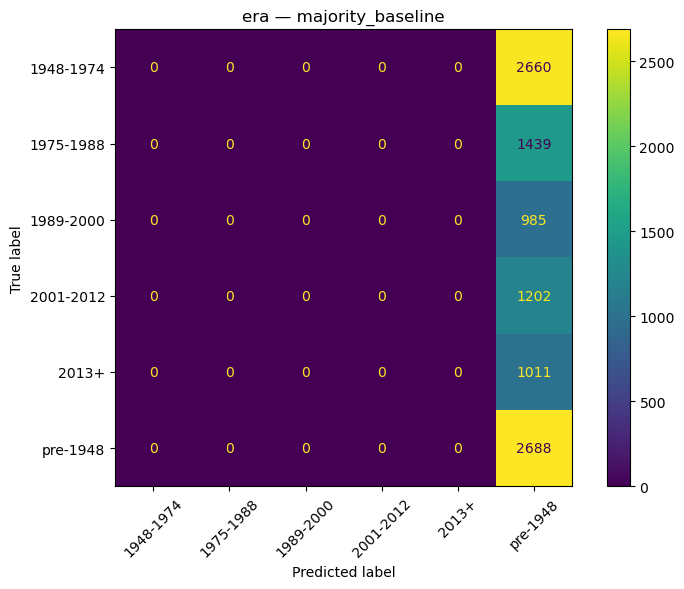

[era] Training: logistic_regression
Accuracy: 0.6583   Macro-F1: 0.6732

Classification report:
              precision    recall  f1-score   support

   1948-1974       0.72      0.53      0.61      2660
   1975-1988       0.50      0.57      0.53      1439
   1989-2000       0.59      0.73      0.65       985
   2001-2012       0.70      0.83      0.76      1202
       2013+       0.77      0.92      0.84      1011
    pre-1948       0.67      0.63      0.65      2688

    accuracy                           0.66      9985
   macro avg       0.66      0.70      0.67      9985
weighted avg       0.66      0.66      0.65      9985



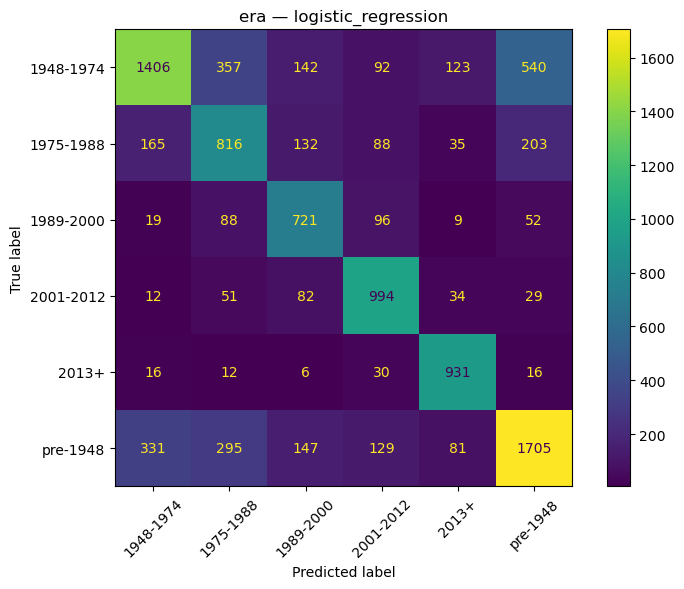

[era] Training: random_forest
Accuracy: 0.7551   Macro-F1: 0.7690

Classification report:
              precision    recall  f1-score   support

   1948-1974       0.82      0.66      0.73      2660
   1975-1988       0.74      0.65      0.69      1439
   1989-2000       0.71      0.79      0.75       985
   2001-2012       0.77      0.86      0.81      1202
       2013+       0.86      0.94      0.90      1011
    pre-1948       0.69      0.77      0.72      2688

    accuracy                           0.76      9985
   macro avg       0.76      0.78      0.77      9985
weighted avg       0.76      0.76      0.75      9985



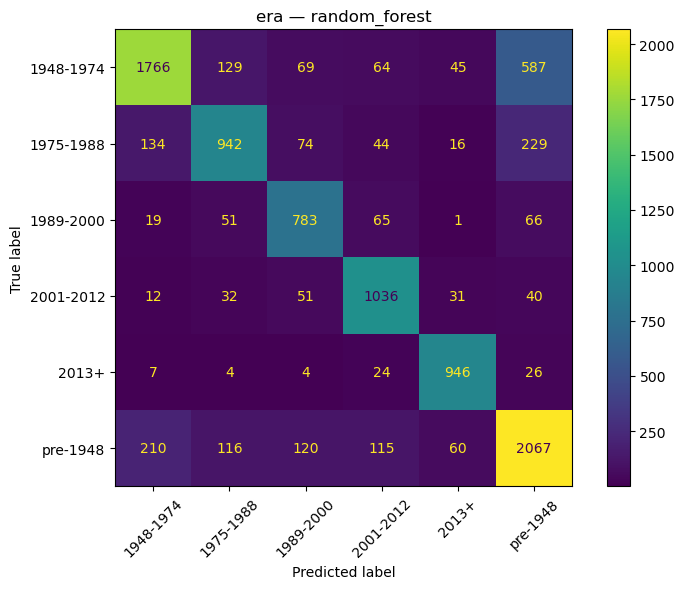

[era] Training: hist_gradient_boosting
Accuracy: 0.7624   Macro-F1: 0.7795

Classification report:
              precision    recall  f1-score   support

   1948-1974       0.77      0.70      0.73      2660
   1975-1988       0.74      0.62      0.68      1439
   1989-2000       0.78      0.77      0.78       985
   2001-2012       0.82      0.86      0.84      1202
       2013+       0.91      0.92      0.92      1011
    pre-1948       0.69      0.80      0.74      2688

    accuracy                           0.76      9985
   macro avg       0.78      0.78      0.78      9985
weighted avg       0.76      0.76      0.76      9985



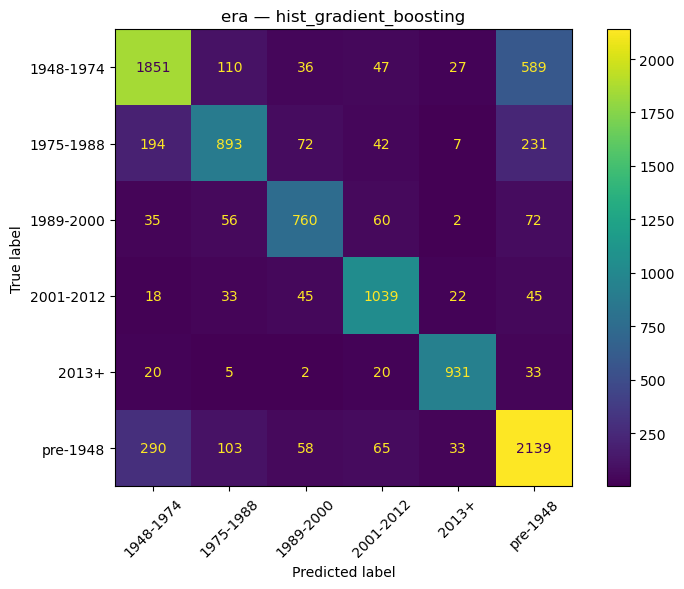

,task,model,accuracy,macro_f1
3,era,hist_gradient_boosting,0.762444,0.779499
2,era,random_forest,0.755133,0.768979
1,era,logistic_regression,0.658287,0.673213
0,era,majority_baseline,0.269204,0.070701


In [9]:
era_results = []
classifiers = make_classifier_pipelines()
for name, model in classifiers.items():
    era_results.append(evaluate_classifier(name, model, X_train, X_test, y_era_train, y_era_test, "era"))

era_df = pd.DataFrame(era_results).sort_values("macro_f1", ascending=False)
era_df

## 9. Task B — Binary pre/post-1975 classification

[binary] Training: majority_baseline
Accuracy: 0.5356   Macro-F1: 0.3488

Classification report:
              precision    recall  f1-score   support

   post-1975       0.00      0.00      0.00      4637
    pre-1975       0.54      1.00      0.70      5348

    accuracy                           0.54      9985
   macro avg       0.27      0.50      0.35      9985
weighted avg       0.29      0.54      0.37      9985



/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

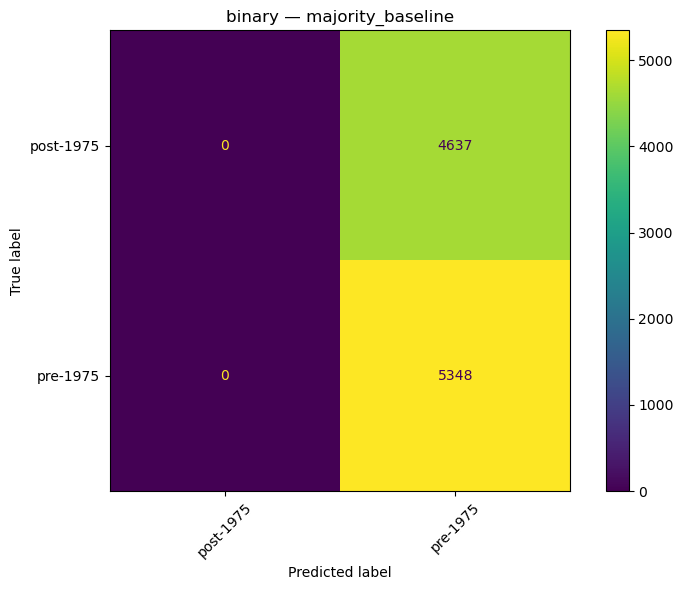

[binary] Training: logistic_regression
Accuracy: 0.8084   Macro-F1: 0.8080

Classification report:
              precision    recall  f1-score   support

   post-1975       0.78      0.82      0.80      4637
    pre-1975       0.84      0.80      0.82      5348

    accuracy                           0.81      9985
   macro avg       0.81      0.81      0.81      9985
weighted avg       0.81      0.81      0.81      9985



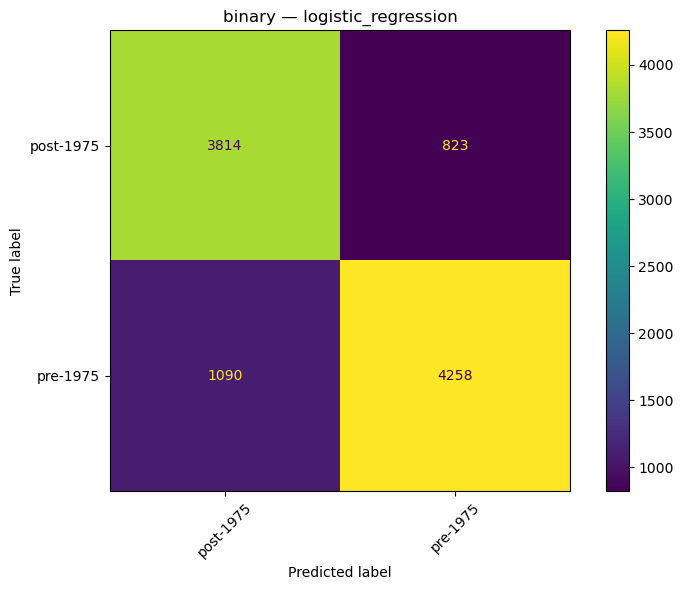

[binary] Training: random_forest
Accuracy: 0.8816   Macro-F1: 0.8808

Classification report:
              precision    recall  f1-score   support

   post-1975       0.88      0.86      0.87      4637
    pre-1975       0.88      0.90      0.89      5348

    accuracy                           0.88      9985
   macro avg       0.88      0.88      0.88      9985
weighted avg       0.88      0.88      0.88      9985



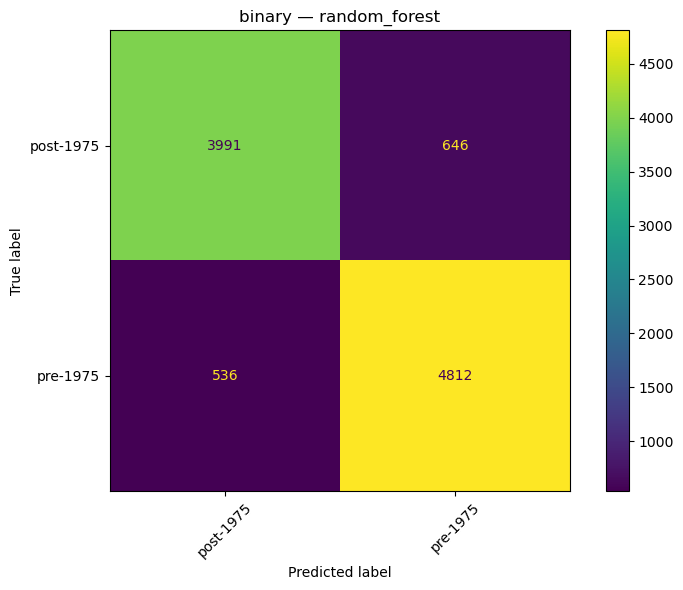

[binary] Training: hist_gradient_boosting
Accuracy: 0.8696   Macro-F1: 0.8688

Classification report:
              precision    recall  f1-score   support

   post-1975       0.87      0.85      0.86      4637
    pre-1975       0.87      0.89      0.88      5348

    accuracy                           0.87      9985
   macro avg       0.87      0.87      0.87      9985
weighted avg       0.87      0.87      0.87      9985



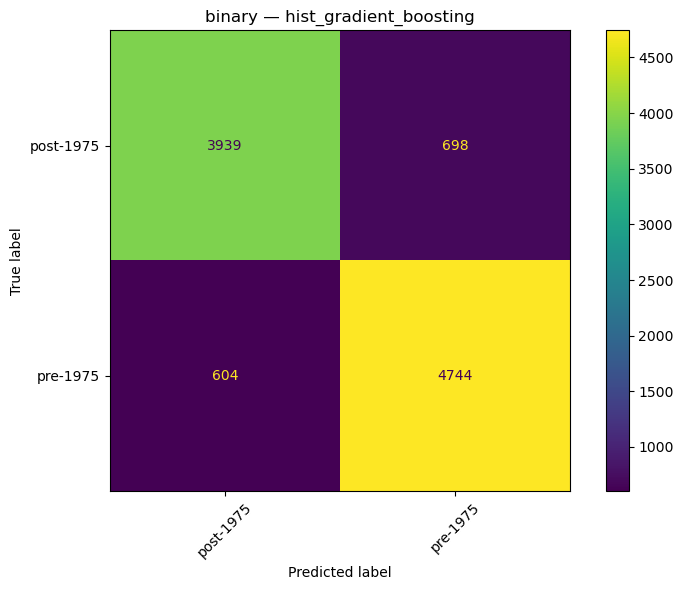

,task,model,accuracy,macro_f1
2,binary,random_forest,0.881622,0.880817
3,binary,hist_gradient_boosting,0.869604,0.868751
1,binary,logistic_regression,0.808413,0.808033
0,binary,majority_baseline,0.535603,0.348790


In [10]:
binary_results = []
classifiers = make_classifier_pipelines()  # fresh pipelines (avoid refitting the same fitted objects)
for name, model in classifiers.items():
    binary_results.append(evaluate_classifier(name, model, X_train, X_test, y_binary_train, y_binary_test, "binary"))

binary_df = pd.DataFrame(binary_results).sort_values("macro_f1", ascending=False)
binary_df

## 10. Task C — Regression on exact construction year

Restricted to the ~58% of rows that have a non-null `annee_construction`. MAE is the headline metric (interpretable as "average error in years").

In [11]:
regression_results = []
regressors = make_regressor_pipelines()
for name, model in regressors.items():
    regression_results.append(evaluate_regressor(name, model, X_train_yr, X_test_yr, y_year_train, y_year_test))

reg_df = pd.DataFrame(regression_results).sort_values("mae")
reg_df

[regression] Training: mean_baseline
MAE: 26.00 years   RMSE: 36.83   R^2: -0.0004
[regression] Training: ridge


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


MAE: 18.77 years   RMSE: 30.11   R^2: 0.3316
[regression] Training: random_forest_reg


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


MAE: 12.20 years   RMSE: 26.72   R^2: 0.4735
[regression] Training: hist_gradient_boosting_reg
MAE: 14.96 years   RMSE: 27.23   R^2: 0.4533


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,task,model,mae,rmse,r2
2,regression,random_forest_reg,12.202652,26.719521,0.473536
3,regression,hist_gradient_boosting_reg,14.964345,27.227905,0.453312
1,regression,ridge,18.765031,30.106168,0.331622
0,regression,mean_baseline,25.996039,36.831726,-0.000358


## 11. Cross-validation (primary task: era classification)

5-fold stratified CV on the training set only. The held-out 20% test set above is left untouched for the final reported numbers.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []
classifiers = make_classifier_pipelines()
for name, model in classifiers.items():
    print(f"CV: {name}")
    scores = cross_validate(model, X_train, y_era_train, cv=cv, scoring=["accuracy", "f1_macro"], n_jobs=-1)
    cv_results.append({
        "model": name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_macro_f1_mean": scores["test_f1_macro"].mean(),
        "cv_macro_f1_std": scores["test_f1_macro"].std(),
    })
cv_df = pd.DataFrame(cv_results).sort_values("cv_macro_f1_mean", ascending=False)
cv_df

CV: majority_baseline
CV: logistic_regression
CV: random_forest
CV: hist_gradient_boosting


,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std
3,hist_gradient_boosting,0.762670,0.004823,0.778349,0.004887
2,random_forest,0.751502,0.005428,0.765276,0.005482
1,logistic_regression,0.652945,0.009756,0.667564,0.010971
0,majority_baseline,0.269206,0.000055,0.070702,0.000011


## 12. Feature ablation (primary task: era classification)

Four feature sets per spec section 6, experiment 4:

| Set | Contains |
|---|---|
| `energy_only` | Energy features + energy-derived engineered features |
| `structural_only` | Structural features + structural-derived engineered features |
| `combined` | All features |
| `combined_minus_leaky` | All features **except** `type_generateur_chauffage_principal` and `type_ventilation` (potential era proxies) |

Run with cross-validation using Random Forest. The minus-leaky vs combined comparison directly addresses the spec's feature-leakage concern: "is the model learning genuine patterns or just looking up equipment types?"

In [13]:
ablation_sets = {
    "energy_only": ENERGY_FEATURES + ENGINEERED_ENERGY,
    "structural_only": STRUCTURAL_FEATURES + ENGINEERED_STRUCTURAL,
    "combined": ALL_FEATURES,
    "combined_minus_leaky": [c for c in ALL_FEATURES if c not in LEAKY_FEATURES],
}

ablation_results = []
for set_name, cols in ablation_sets.items():
    X_sub = X_train[cols].copy()
    num = X_sub.select_dtypes(include=["number", "bool"]).columns.tolist()
    cat = X_sub.select_dtypes(exclude=["number", "bool"]).columns.tolist()
    pipe = Pipeline([
        ("pre", make_preprocessor(num, cat)),
        ("model", RandomForestClassifier(
            n_estimators=300, min_samples_leaf=2,
            class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE,
        )),
    ])
    print(f"Ablation: {set_name} ({len(cols)} features)")
    scores = cross_validate(pipe, X_sub, y_era_train, cv=cv, scoring=["accuracy", "f1_macro"], n_jobs=-1)
    ablation_results.append({
        "feature_set": set_name,
        "n_features": len(cols),
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "macro_f1_mean": scores["test_f1_macro"].mean(),
        "macro_f1_std": scores["test_f1_macro"].std(),
    })

ablation_df = pd.DataFrame(ablation_results).sort_values("macro_f1_mean", ascending=False)
ablation_df

Ablation: energy_only (11 features)
Ablation: structural_only (16 features)
Ablation: combined (30 features)
Ablation: combined_minus_leaky (28 features)


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,feature_set,n_features,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std
2,combined,30,0.751502,0.005428,0.765276,0.005482
3,combined_minus_leaky,28,0.748473,0.004808,0.761242,0.005038
1,structural_only,16,0.717999,0.004096,0.730224,0.003599
0,energy_only,11,0.628180,0.003725,0.620245,0.003262


## 13. Save results

In [14]:
era_df.to_csv(OUTPUT_DIR / "test_set_era_classification.csv", index=False)
binary_df.to_csv(OUTPUT_DIR / "test_set_binary_classification.csv", index=False)
reg_df.to_csv(OUTPUT_DIR / "test_set_regression.csv", index=False)
cv_df.to_csv(OUTPUT_DIR / "cross_validation_era.csv", index=False)
ablation_df.to_csv(OUTPUT_DIR / "feature_ablation_era.csv", index=False)

for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print(f"- {p}")

- ../reports/modeling/cross_validation_era.csv
- ../reports/modeling/feature_ablation_era.csv
- ../reports/modeling/test_set_binary_classification.csv
- ../reports/modeling/test_set_era_classification.csv
- ../reports/modeling/test_set_regression.csv
